<a href="https://colab.research.google.com/github/ji-xinyi/ji-xinyi.github.io/blob/main/WK07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 07: Analyzing Data with Pandas

In this notebook we'll explore two ways for getting more information from our data: visually and numerically.

Let's download the [Spotify Tracks](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) dataset to see what this means.

In [1]:
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/musical_moods.csv -P ./data
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/spotify_artists.csv -P ./data
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/spotify_tracks.csv -P ./data
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/wines.csv -P ./data

Let's import some libraries.

In [2]:
import csv
import json

import pandas as pd
import matplotlib.pyplot as plt

And now we can load our data from the file into a `DataFrame`.

In [3]:
spotify_df = pd.read_csv("./data/spotify_tracks.csv")
spotify_df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


## Some Basic Information

Like we've done before, but now with a `DataFrame`:
- How many items are in our dataset ?
- What are the features ?
- How are they represented ?

In [5]:
# TODO: get some basic info about the dataset
spotify_df[["popularity", "energy"]].max()

,0
popularity,100.0
energy,1.0


## Some Stats

Extract some features and calculate:
- min/max/average song length
- min/max/average song popularity

With a `DataFrame` this is just `.min()`, `.max()`, `.mean()`.

In [13]:
# TODO: calculate min/max/avg song lengths
display(spotify_df["duration"].min())
display(spotify_df["duration"].max())
display(spotify_df["duration"].mean())

# TODO: calculate min/max/avg song popularity scores
display(spotify_df[["popularity", "energy"]].min())
display(spotify_df[["popularity", "energy"]].max())
display(spotify_df[["popularity", "energy"]].mean())

# TODO: can we calculate min/max for ALL features ?

0.0

87.28825

np.float64(3.800485885233918)

,0
popularity,0.0
energy,0.0


,0
popularity,100.0
energy,1.0


,0
popularity,33.238535
energy,0.641383


In [12]:
# TODO: add a column for duration in minutes
spotify_df["duration"] = spotify_df["duration_ms"]/ 1000 / 60
spotify_df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,6.416650
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,6.416667
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,4.524433
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,4.731550


In [10]:
display(spotify_df["duration"].min())
display(spotify_df["duration"].max())
display(spotify_df["duration"].mean())

0.0

87.28825

np.float64(3.800485885233918)

### Column indexing by design

This means the `DataFrame` functions also operate on columns by default.

In [14]:
# This calculates the mean of all selected columns
spotify_df[["popularity", "duration", "danceability", "energy"]].mean()

,0
popularity,33.238535
duration,3.800486
danceability,0.566800
energy,0.641383


## Plots

The min/max/average values of a feature certainly are important, but it doesn't show us the whole picture of what's happening with our values, and how they might be related or show trends.

One way we can get to know our data better is by visualizing it in plots and graphs.

We'll use the `pyplot` library to plot some simple graphs to see exactly what our features look like.

[`PyPlot` Documentation](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html)

### The `plot()` and `hist()` functions

have ~~some~~ lots of options...

`plot()` [documentation](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.plot.html)

`hist()` [documentation](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.hist.html)

Adjusting some of these can help improve the legibility of our graph.

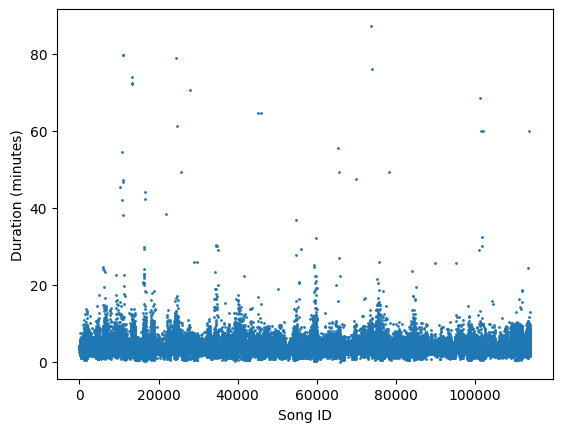

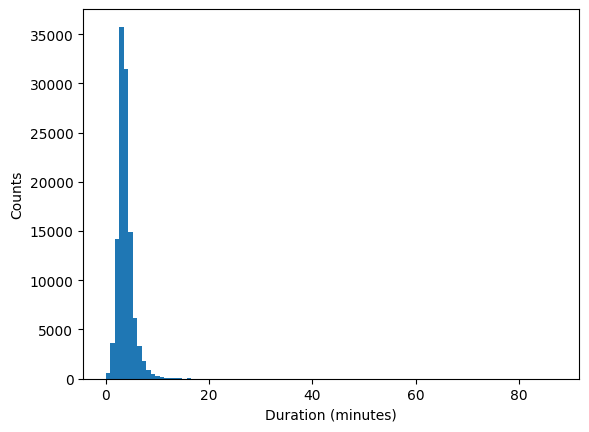

In [15]:
plt.plot(spotify_df["duration"], linestyle="", marker="o", markersize=1)
plt.xlabel("Song ID")
plt.ylabel("Duration (minutes)")
plt.show()

plt.hist(spotify_df["duration"], bins=100)
plt.xlabel("Duration (minutes)")
plt.ylabel("Counts")
plt.show()

### Repeat for the `popularity` feature

In [16]:
# TODO: Plot the scatter points and the histogram for the popularity feature

### And other features

In [17]:
# TODO: extract and plot other numerical values from dataset, like:
#       danceability, energy, loudness

## Relationship between features

Are longer songs more popular ? Are shorter songs more popular ?

We can use the `plot()` function, and instead of plotting a single feature, give it $2$ features, to see our `popularity` and `duration` data on the same graph at the same time.

In [ ]:
plt.plot(spotify_df["duration"], spotify_df["popularity"], linestyle="", marker="o", markersize=1, alpha=0.2)
plt.xlabel("Duration (min)")
plt.ylabel("Popularity Score")
plt.show()

Each dot still represents a song, but now it's horizontal position is determined by its `duration` and its vertical position by its `popularity`.

This helps us see trends.

### Filter !

Let's filter the data and only plot songs with a duration between $1$ and $10$ minutes, and popularity greater than $15$.

We'll use _conditional indexing_ and boolean operations.

In [19]:
# TODO: filter
# TODO: plot
spotify_fil_df = spotify_df[(spotify_df["duration"])]

plt.hist(spotify_df["duration"], bins=100)
plt.xlabel("Duration (minutes)")
plt.ylabel("Counts")
plt.show()

bin_id, bin_dur = pd.cut(dur_pop_df["duration"]), bins = 16,

KeyError: "None of [Index([3.8444333333333334,             2.4935, 3.5137666666666667,\n                  3.36555,  3.314216666666667,  3.570666666666667,\n       3.8233333333333333,             4.0491, 3.1602166666666665,\n       3.4265666666666665,\n       ...\n        6.150816666666667,            4.17715,  5.209433333333333,\n                   4.2671,             5.0909,  6.416650000000001,\n        6.416666666666667, 4.5244333333333335, 4.7315499999999995,\n        4.030433333333333],\n      dtype='float64', length=114000)] are in the [columns]"

### But, is it ?

Are songs around $3.8$ minutes more popular ? Or do they just seem more popular on the graph because there's more of them ?

To anser this, we can group our tracks by duration and measure the average popularity score of each group.

This makes the popularity scores in each group independent of the size of the group.

In [18]:
# TODO: copy duration and popularity
dur_pop_df = spotify_fil_df[["duration","popularity"]].copy()
# TODO: bin data into 16 categories by duration (in pandas it's called cut)
#       labels=False and retbins=True to get numerical categories and the bin labels

pd.cut(dur_pop_df["duration"], bins=16, labels="false,", retbins=True)
dur_pop_df["duration_bin"] = bin_ids

# TODO: group by bin, and take average of popularity
dur_pop_df.groupby("duration_bin")["popularity"].mean()

# TODO: plot
plt.plot(bin_dur:10)

# TODO: plot duration histogram

NameError: name 'spotify_fil_df' is not defined

### So.... are long songs more popular ?

We can look at the graph above, but we can also compute a correlation _score_ for our variables.

This is another function we have in the `DataFrame`, like `mean()` or `max()`.

In [ ]:
# Let's use the filtered values

# First, get numerical column names
num_cols = spotify_fil_df.select_dtypes(include=[float, int]).columns

# get correlation matrix
spotify_fil_float_df[num_cols].corr()

### Repeat !

Take a look at the correlation matrix and plot some other pairs of correlated features.

In [ ]:
# TODO: look at correlation matrix
# TODO: plot pairs of values that might be correlated

## Combining Data Sources

Let's add artist info and song mood info to our dataset.

We'll ***join*** our song `DataFrame` with a separate `DataFrame` that has information about artists and a third `DataFrame` that has information about musical key and mood.

This can be done with the functions `merge()` or `join()`. These functions do the same thing.

By default, `join()` combines `DataFrame`s based on row indices and `merge()` combines by column names, but they can both be used to combine by row indices or column names.

Here's a [guide](https://pandas.pydata.org/docs/user_guide/merging.html) about merging data, and the technical details of [`join()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html) and [`merge()`](https://pandas.pydata.org/docs/reference/api/pandas.merge.html).

In [ ]:
# TODO: open spotify_artists.csv

In [ ]:
# TODO: merge(tracks, artists) on "artists", "Artist Name"

### Add song mood info

In [ ]:
# TODO: open musical_moods.csv
# TODO: merge (tracks, moods) on ("key","mode") , ("key_num", "mode")

## Questions

- Who's the artist with the most tracks ?
- Who wrote the longest song with a popularity score greater than $50$ ?
- How long is it ?
- Are "explicit" songs more popular ?
- Which of the following is more popular: _reggaeton_, _sertanejo_, _pagode_, _samba_ or _salsa_ ?
- Which is louder ?

## Wine Revisited

Let's revisit some of the questions from Homework $02$ and try to do them with `DataFrame`:

In [ ]:
wines_df = pd.read_csv("./data/wines.csv")
wines_df

In [ ]:
# What's the average rating for California wines ?
# (we can filter and then index the filtered data by column)

ca_points = wines_df[wines_df["province"] == "California"]["points"]
sum(ca_points) / len(ca_points)

# OR:
# wines_df[wines_df["province"] == "California"]["points"].mean()

In [ ]:
# What's the most expensive wine from Spain ?
# (filter and sort by column, then select the first row with iloc[0])

wines_df[wines_df["country"] == "Spain"].sort_values("price", ascending=False).iloc[0]


In [ ]:
# Where's the worse wine in the US from ?
# (filter by country, sort by points, then get designation, province, region and winery columns for first row)

wines_df[wines_df["country"] == "US"].sort_values("points").iloc[0][["designation", "province", "region", "winery"]]

In [ ]:
# Which country between spain/us/france has highest average price ?
# (group by country, select column, get average/mean, select countries, sort)

wines_df.groupby("country")["price"].mean()[["US", "Spain", "France"]].sort_values()

In [ ]:
# Which country between spain/us/france has highest average quality points ?
# (group by country, select column, get average/mean, select countries, sort)

wines_df.groupby("country")["points"].mean()[["US", "Spain", "France"]].sort_values()

### That last question, finally:

*Are the best wines also the most expensive ?*

We can plot wine `prices` and `points` now to get a more accurate answer to this question.

In [ ]:
plt.plot(wines_df["points"], wines_df["price"], linestyle="", marker="o", alpha=0.1)
plt.ylim([0, 150])
plt.show()

### Hmmm...

Kind of...

Maybe the most expensive wine is not the highest rated, but looking at all wines at the same time, it looks like the prices do go up as points increase.

We can measure how much. There's a statistical property that measures how much two features change together: correlation.

If two features have correlation close to $1$ or $-1$, there's a strong relationship between them.

If the correlation is close to $0$, then one feature doesn't tell us anything about the other.

It's common to get values in between $0$ and $1$...

In `pandas` we can do this with:

`wines_df[["price", "points"]].corr()`

In [ ]:
wines_df[["price", "points"]].corr()